# **Importing the libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Importing the dataset**

In [5]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
dataset = pd.read_csv(url)
dataset.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [6]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:, -1].values

In [7]:
print(X)

[[19 'female' 27.9 0 'yes' 'southwest']
 [18 'male' 33.77 1 'no' 'southeast']
 [28 'male' 33.0 3 'no' 'southeast']
 ...
 [18 'female' 36.85 0 'no' 'southeast']
 [21 'female' 25.8 0 'no' 'southwest']
 [61 'female' 29.07 0 'yes' 'northwest']]


In [8]:
print(y)

[16884.924   1725.5523  4449.462  ...  1629.8335  2007.945  29141.3603]


## **Missing values**

In [9]:
dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# **Adding one missing value in "bmi"**

In [11]:
dataset.loc[5, "bmi"] = np.nan

In [12]:
dataset.isnull().sum()

,0
age,0
sex,0
bmi,1
children,0
smoker,0
region,0
charges,0


# **Taking care of missing values**

In [13]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

# Impute the 'bmi' column directly in the dataset DataFrame
# SimpleImputer expects a 2D array, so we pass dataset[['bmi']]
dataset['bmi'] = imputer.fit_transform(dataset[['bmi']])

# Now, the 'bmi' column in 'dataset' should have no missing values.

In [14]:
print(X)

[[19 'female' 27.9 0 'yes' 'southwest']
 [18 'male' 33.77 1 'no' 'southeast']
 [28 'male' 33.0 3 'no' 'southeast']
 ...
 [18 'female' 36.85 0 'no' 'southeast']
 [21 'female' 25.8 0 'no' 'southwest']
 [61 'female' 29.07 0 'yes' 'northwest']]


In [15]:
print(dataset['bmi'])

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64


In [16]:
dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# **Encoding categorical data**(independent variable)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[1,4,5])],remainder='passthrough')
X= np.array(ct.fit_transform(X))



In [18]:
print(X)

[[1.0 0.0 0.0 ... 19 27.9 0]
 [0.0 1.0 1.0 ... 18 33.77 1]
 [0.0 1.0 1.0 ... 28 33.0 3]
 ...
 [1.0 0.0 1.0 ... 18 36.85 0]
 [1.0 0.0 1.0 ... 21 25.8 0]
 [1.0 0.0 0.0 ... 61 29.07 0]]


In [19]:
print(X.shape[1])

11


In [20]:
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# **Train test set split**

In [21]:
from sklearn.model_selection import train_test_split
X_train , X_test, y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [22]:
print(len(y_train))

1070


In [23]:
print(len(y_test))

268


In [24]:
print(X_train)

[[1.0 0.0 1.0 ... 53 26.6 0]
 [0.0 1.0 1.0 ... 53 21.4 1]
 [0.0 1.0 1.0 ... 18 37.29 0]
 ...
 [1.0 0.0 0.0 ... 51 34.96 2]
 [1.0 0.0 0.0 ... 40 22.22 2]
 [0.0 1.0 1.0 ... 57 27.94 1]]


In [25]:
print(X_test)

[[0.0 1.0 1.0 ... 19 35.53 0]
 [0.0 1.0 1.0 ... 57 31.54 0]
 [0.0 1.0 1.0 ... 51 37.0 0]
 ...
 [0.0 1.0 0.0 ... 47 38.94 2]
 [1.0 0.0 1.0 ... 19 36.575 0]
 [1.0 0.0 1.0 ... 35 26.125 0]]


In [26]:
print(y_train)

[10355.641  10065.413   1141.4451 ... 44641.1974 19444.2658 11554.2236]


In [27]:
print(y_test)

[ 1646.4297  11353.2276   8798.593   10381.4787   2103.08    38746.3551
  9304.7019  11658.11505  3070.8087  19539.243   12629.8967  11538.421
  6338.0756   7050.642    1137.4697   8968.33    21984.47061  6414.178
 28287.89766 13462.52     9722.7695  40932.4295   8026.6666   8444.474
  2203.47185  6664.68595  8606.2174   8283.6807   5375.038    3645.0894
 11674.13    11737.84884 24873.3849  33750.2918  24180.9335   9863.4718
 36837.467   17942.106   11856.4115  39725.51805  4349.462   11743.9341
 19749.38338 12347.172    4931.647   30259.99556 27724.28875 34672.1472
  9644.2525  14394.39815 12557.6053  11881.358    2352.96845  9101.798
 17178.6824   3994.1778  40941.2854  12644.589   22395.74424  1149.3959
  3366.6697  13143.33665 18328.2381   2690.1138  12741.16745  8765.249
 10264.4421  22192.43711  2709.24395 14571.8908  60021.39897 58571.07448
  1743.214   12479.70895 13352.0998  41034.2214   2789.0574   2867.1196
 11070.535   10493.9458   3167.45585 12269.68865 10942.13205  1977.8

In [28]:
from sklearn.preprocessing import StandardScaler
sc_X=StandardScaler()
sc_y=StandardScaler()



In [29]:
# Apply StandardScaler to the numerical columns (age, bmi, children) at indices 8, 9, 10
# Fit on X_train and transform both X_train and X_test and y_train and y_test
X_train[:, [8, 9, 10]] = sc_X.fit_transform(X_train[:, [8, 9, 10]])
y_train = sc_y.fit_transform(y_train.reshape(-1, 1))

X_test[:, [8, 9, 10]] = sc_X.transform(X_test[:, [8, 9, 10]])
y_test = sc_y.transform(y_test.reshape(-1, 1))

# **Let's check the first few rows of the scaled `X_train` and `X_test` to see the effect of standardization on the numerical columns.**

In [30]:
print('Scaled X_train:')
print(X_train) #all rows in X_train


Scaled X_train:
[[1.0 0.0 1.0 ... 1.0022862943641635 -0.664744719547023
  -0.9070577122378723]
 [0.0 1.0 1.0 ... 1.0022862943641635 -1.514023685056975
  -0.07894188280568516]
 [0.0 1.0 1.0 ... -1.5042660745131609 1.0811768460878584
  -0.9070577122378723]
 ...
 [1.0 0.0 0.0 ... 0.8590547304283164 0.700634540388207 0.749173946626502]
 [1.0 0.0 0.0 ... 0.0712811287811573 -1.380098925111175 0.749173946626502]
 [0.0 1.0 1.0 ... 1.2887494222358578 -0.44589206305022766
  -0.07894188280568516]]


In [31]:
print('Scaled X_train:')
print(X_train[:5])

print('\nScaled X_test:')
print(X_test[:5])

Scaled X_train:
[[1.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 1.0022862943641635 -0.664744719547023
  -0.9070577122378723]
 [0.0 1.0 1.0 0.0 0.0 0.0 0.0 1.0 1.0022862943641635 -1.514023685056975
  -0.07894188280568516]
 [0.0 1.0 1.0 0.0 0.0 0.0 1.0 0.0 -1.5042660745131609 1.0811768460878584
  -0.9070577122378723]
 [1.0 0.0 1.0 0.0 0.0 1.0 0.0 0.0 1.5035967681396283 -1.0836679015726052
  -0.9070577122378723]
 [0.0 1.0 1.0 0.0 0.0 0.0 0.0 1.0 0.42936003862077504 0.4948477141300268
  -0.07894188280568516]]

Scaled X_test:
[[0.0 1.0 1.0 0.0 0.0 1.0 0.0 0.0 -1.4326502925452373 0.7937285808383364
  -0.9070577122378723]
 [0.0 1.0 1.0 0.0 0.0 1.0 0.0 0.0 1.2887494222358578 0.14207029768743087
  -0.9070577122378723]
 [0.0 1.0 1.0 0.0 0.0 0.0 0.0 1.0 0.8590547304283164 1.0338132114728804
  -0.9070577122378723]
 [1.0 0.0 1.0 0.0 0.0 0.0 1.0 0.0 0.7158231664924692 0.9733837466192881
  1.5772897760586893]
 [0.0 1.0 1.0 0.0 0.0 0.0 0.0 1.0 -1.28941872860939 -1.36703309487256
  -0.07894188280568516]]


# **Multiple linear regression on training set**

In [32]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

# **Predicting test set results**

In [33]:
#we want to represent the result in 2D array so we need 2 ventors
#y_pred is for predicted charges in the test set
#y_test is for real charges in the test set

In [34]:
print(dataset['charges'].describe())

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


In [35]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))


[[-7.33e-01 -9.59e-01]
 [-2.86e-02 -1.55e-01]
 [-5.31e-02 -3.67e-01]
 [ 4.64e-03 -2.36e-01]
 [-1.05e+00 -9.21e-01]
 [ 1.56e+00  2.11e+00]
 [-2.58e-02 -3.25e-01]
 [-7.55e-02 -1.30e-01]
 [-7.82e-01 -8.41e-01]
 [ 1.34e+00  5.22e-01]
 [-1.84e-01 -4.97e-02]
 [ 3.57e-01 -1.40e-01]
 [-3.77e-01 -5.71e-01]
 [-4.04e-01 -5.12e-01]
 [-8.36e-01 -1.00e+00]
 [-2.31e-01 -3.53e-01]
 [-7.76e-01  7.25e-01]
 [-5.20e-01 -5.64e-01]
 [ 1.47e-01  1.25e+00]
 [ 1.00e-01  1.92e-02]
 [-5.68e-02 -2.90e-01]
 [ 1.63e+00  2.29e+00]
 [-3.44e-01 -4.31e-01]
 [-3.51e-01 -3.96e-01]
 [-8.45e-01 -9.13e-01]
 [-4.19e-01 -5.44e-01]
 [-3.04e-01 -3.83e-01]
 [-2.06e-01 -4.10e-01]
 [-4.58e-01 -6.50e-01]
 [-7.33e-01 -7.94e-01]
 [ 7.54e-02 -1.29e-01]
 [-6.14e-01 -1.24e-01]
 [ 1.77e+00  9.64e-01]
 [ 1.14e+00  1.70e+00]
 [ 1.67e+00  9.07e-01]
 [-3.06e-01 -2.79e-01]
 [ 1.42e+00  1.95e+00]
 [ 1.11e+00  3.90e-01]
 [ 1.60e-01 -1.14e-01]
 [ 1.71e+00  2.19e+00]
 [-5.74e-01 -7.35e-01]
 [ 6.86e-02 -1.23e-01]
 [-2.08e-01  5.40e-01]
 [ 1.54e-01

# **Evaluating model performance(MLR)**

In [36]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.7623311844057112

# **Polynomial Regression**

In [37]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create a PolynomialFeatures object with degree 2
poly_reg = PolynomialFeatures(degree = 2)

# Transform X_train and X_test to include polynomial features
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

# Train a Linear Regression model on the polynomial features
poly_regressor = LinearRegression()
poly_regressor.fit(X_train_poly, y_train)

LinearRegression()

# **Predicting with Polynomial Regression and Evaluating Performance**

In [38]:
y_pred_poly = poly_regressor.predict(X_test_poly)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred_poly.reshape(len(y_pred_poly),1), y_test.reshape(len(y_test),1)),1))


[[-8.11e-01 -9.59e-01]
 [-5.46e-02 -1.55e-01]
 [-2.42e-01 -3.67e-01]
 [-1.36e-01 -2.36e-01]
 [-8.88e-01 -9.21e-01]
 [ 1.87e+00  2.11e+00]
 [-1.88e-01 -3.25e-01]
 [-4.72e-02 -1.30e-01]
 [-7.25e-01 -8.41e-01]
 [ 9.21e-01  5.22e-01]
 [ 9.24e-02 -4.97e-02]
 [-1.43e-01 -1.40e-01]
 [-4.32e-01 -5.71e-01]
 [-4.01e-01 -5.12e-01]
 [-9.22e-01 -1.00e+00]
 [-2.51e-01 -3.53e-01]
 [-7.52e-01  7.25e-01]
 [-4.61e-01 -5.64e-01]
 [ 9.77e-02  1.25e+00]
 [ 1.38e-01  1.92e-02]
 [-1.53e-01 -2.90e-01]
 [ 2.26e+00  2.29e+00]
 [-3.83e-01 -4.31e-01]
 [-3.02e-01 -3.96e-01]
 [-6.68e-01 -9.13e-01]
 [-4.26e-01 -5.44e-01]
 [-2.41e-01 -3.83e-01]
 [-3.05e-01 -4.10e-01]
 [-5.42e-01 -6.50e-01]
 [-6.94e-01 -7.94e-01]
 [-1.18e-02 -1.29e-01]
 [-6.12e-01 -1.24e-01]
 [ 9.64e-01  9.64e-01]
 [ 1.33e+00  1.70e+00]
 [ 1.18e+00  9.07e-01]
 [-2.67e-01 -2.79e-01]
 [ 1.91e+00  1.95e+00]
 [ 5.72e-01  3.90e-01]
 [-3.43e-02 -1.14e-01]
 [ 1.64e+00  2.19e+00]
 [-6.22e-01 -7.35e-01]
 [-5.28e-04 -1.23e-01]
 [-3.45e-02  5.40e-01]
 [ 7.85e-02

# **Visualising polynomial regression result**

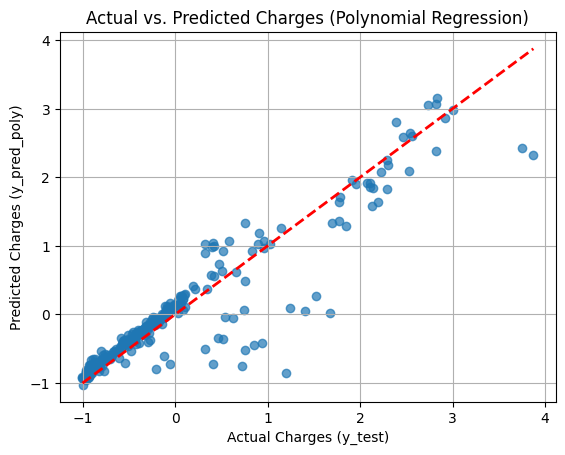

In [39]:

plt.scatter(y_test, y_pred_poly, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Charges (y_test)")
plt.ylabel("Predicted Charges (y_pred_poly)")
plt.title("Actual vs. Predicted Charges (Polynomial Regression)")
plt.grid(True)
plt.show()

# **Evaluating polynomial regression model performance**

In [40]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_poly)

0.8625622877973305

# **SVR on training set**

In [70]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X_train,y_train.ravel())

SVR()

In [71]:
y_pred_svr = regressor.predict(X_test)
np.printoptions(precision=2)
print(np.concatenate((y_pred_svr.reshape(len(y_pred_svr),1), y_test.reshape(len(y_test),1)),1))

[[-0.86 -0.96]
 [-0.06 -0.16]
 [-0.27 -0.37]
 [-0.1  -0.24]
 [-0.94 -0.92]
 [ 1.9   2.11]
 [-0.27 -0.33]
 [-0.04 -0.13]
 [-0.8  -0.84]
 [ 0.56  0.52]
 [ 0.04 -0.05]
 [-0.04 -0.14]
 [-0.51 -0.57]
 [-0.43 -0.51]
 [-0.9  -1.  ]
 [-0.3  -0.35]
 [-0.77  0.72]
 [-0.47 -0.56]
 [ 0.05  1.25]
 [ 0.12  0.02]
 [-0.19 -0.29]
 [ 2.04  2.29]
 [-0.34 -0.43]
 [-0.3  -0.4 ]
 [-0.81 -0.91]
 [-0.49 -0.54]
 [-0.33 -0.38]
 [-0.33 -0.41]
 [-0.54 -0.65]
 [-0.76 -0.79]
 [-0.03 -0.13]
 [-0.64 -0.12]
 [ 0.71  0.96]
 [ 1.09  1.7 ]
 [ 0.88  0.91]
 [-0.21 -0.28]
 [ 2.11  1.95]
 [ 0.18  0.39]
 [-0.02 -0.11]
 [ 1.69  2.19]
 [-0.67 -0.74]
 [-0.02 -0.12]
 [-0.11  0.54]
 [ 0.01 -0.07]
 [-0.59 -0.69]
 [ 0.03  1.41]
 [-0.85  1.2 ]
 [ 1.29  1.78]
 [-0.16 -0.3 ]
 [ 0.11  0.1 ]
 [ 0.05 -0.06]
 [-0.01 -0.11]
 [-0.95 -0.9 ]
 [-0.24 -0.34]
 [ 0.72  0.33]
 [-0.63 -0.76]
 [ 1.75  2.29]
 [ 0.05 -0.05]
 [-0.66  0.76]
 [-0.9  -1.  ]
 [-0.75 -0.82]
 [ 0.08 -0.01]
 [ 0.83  0.42]
 [-0.8  -0.87]
 [ 0.06 -0.04]
 [-0.29 -0.37]
 [-0.17 -0

In [48]:
y_pred_org=sc_y.inverse_transform(y_pred_svr.reshape(-1,1))


In [49]:
y_test_org=sc_y.inverse_transform(y_test.reshape(-1,1))

# **Visualising the SVR result**

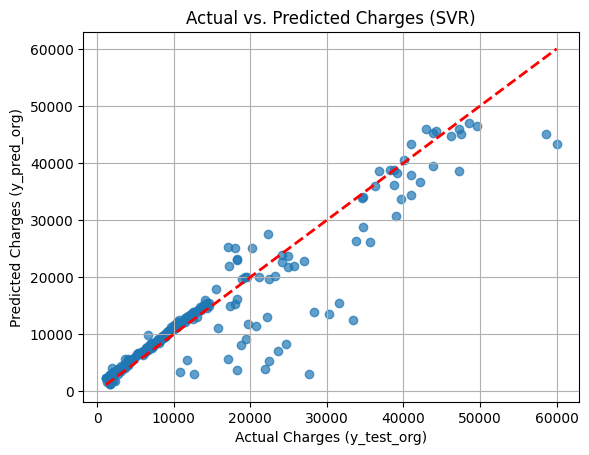

In [72]:
plt.scatter(y_test_org, y_pred_org, alpha=0.7)
plt.plot([y_test_org.min(), y_test_org.max()], [y_test_org.min(), y_test_org.max()], 'r--', lw=2)
plt.xlabel("Actual Charges (y_test_org)")
plt.ylabel("Predicted Charges (y_pred_org)")
plt.title("Actual vs. Predicted Charges (SVR)")
plt.grid(True)
plt.show()

# **Evaluating SVR model performance**

In [51]:
from sklearn.metrics import r2_score
r2_score(y_test_org,y_pred_org)

0.8628653783011315

# **Decision Tree Regression on training set**

In [52]:
from sklearn.tree import DecisionTreeRegressor
reg=DecisionTreeRegressor(random_state=0)
reg.fit(X_train,y_train)

DecisionTreeRegressor(random_state=0)

In [53]:
y_pred_dt = reg.predict(X_test)
np.printoptions(precision=2)
print(np.concatenate((y_pred_dt.reshape(len(y_pred_dt),1),y_test.reshape(len(y_test),1)),1))

[[-9.91e-01 -9.59e-01]
 [-1.15e-01 -1.55e-01]
 [-3.18e-01 -3.67e-01]
 [-1.87e-01 -2.36e-01]
 [-9.33e-01 -9.21e-01]
 [ 2.22e+00  2.11e+00]
 [-3.46e-01 -3.25e-01]
 [-1.30e-01 -1.30e-01]
 [-8.01e-01 -8.41e-01]
 [ 5.85e-01  5.22e-01]
 [ 9.34e-01 -4.97e-02]
 [-4.84e-02 -1.40e-01]
 [-5.49e-01 -5.71e-01]
 [-5.35e-01 -5.12e-01]
 [-1.00e+00 -1.00e+00]
 [-2.99e-01 -3.53e-01]
 [-7.17e-01  7.25e-01]
 [-6.05e-01 -5.64e-01]
 [ 1.22e+00  1.25e+00]
 [ 5.09e-02  1.92e-02]
 [-3.39e-01 -2.90e-01]
 [ 2.15e+00  2.29e+00]
 [ 1.25e+00 -4.31e-01]
 [-3.68e-01 -3.96e-01]
 [ 6.72e-01 -9.13e-01]
 [-5.66e-01 -5.44e-01]
 [-5.65e-01 -3.83e-01]
 [-4.10e-01 -4.10e-01]
 [-6.00e-01 -6.50e-01]
 [-8.01e-01 -7.94e-01]
 [-2.08e-01 -1.29e-01]
 [-6.91e-01 -1.24e-01]
 [ 1.81e+00  9.64e-01]
 [ 1.96e+00  1.70e+00]
 [ 7.24e-01  9.07e-01]
 [-2.32e-01 -2.79e-01]
 [ 2.60e+00  1.95e+00]
 [ 2.49e-01  3.90e-01]
 [-1.54e-01 -1.14e-01]
 [ 2.30e+00  2.19e+00]
 [-6.70e-01 -7.35e-01]
 [-1.06e-01 -1.23e-01]
 [-2.09e-01  5.40e-01]
 [ 1.66e-01

In [55]:
y_pred_dt_org = sc_y.inverse_transform(y_pred_dt.reshape(-1, 1))
y_test_org = sc_y.inverse_transform(y_test.reshape(-1, 1))



# **Visualising Decision Tree result**

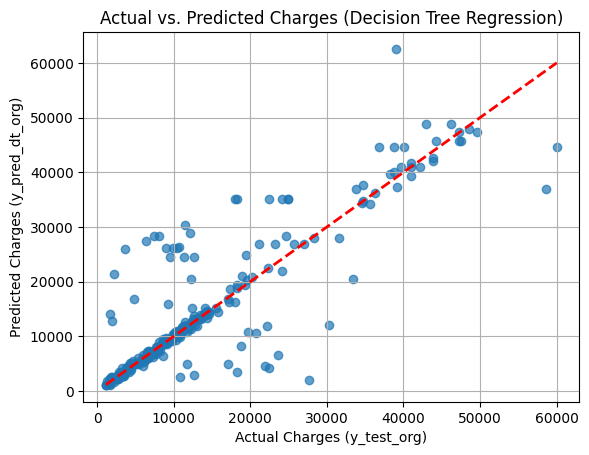

In [56]:
plt.scatter(y_test_org, y_pred_dt_org, alpha=0.7)
plt.plot([y_test_org.min(), y_test_org.max()], [y_test_org.min(), y_test_org.max()], 'r--', lw=2)
plt.xlabel("Actual Charges (y_test_org)")
plt.ylabel("Predicted Charges (y_pred_dt_org)")
plt.title("Actual vs. Predicted Charges (Decision Tree Regression)")
plt.grid(True)
plt.show()

# **Evaluating Decision Tree Regression model performance**

In [57]:
from sklearn.metrics import r2_score
r2_score(y_test_org,y_pred_dt_org)

0.732897690267666

# **Random Forest Regression on training set**

In [63]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 100, random_state = 0)
regressor.fit(X_train, y_train.ravel())

RandomForestRegressor(random_state=0)

In [66]:
y_pred_rf = regressor.predict(X_test)
np.printoptions(precision=2)
print(np.concatenate((y_pred_rf.reshape(len(y_pred_rf),1),y_test.reshape(len(y_test),1)),1))

[[-9.46e-01 -9.59e-01]
 [-1.09e-01 -1.55e-01]
 [-3.38e-01 -3.67e-01]
 [-1.83e-01 -2.36e-01]
 [-9.19e-01 -9.21e-01]
 [ 2.22e+00  2.11e+00]
 [-2.45e-01 -3.25e-01]
 [-1.32e-01 -1.30e-01]
 [-7.34e-01 -8.41e-01]
 [ 5.54e-01  5.22e-01]
 [ 3.33e-01 -4.97e-02]
 [-6.99e-02 -1.40e-01]
 [-5.09e-01 -5.71e-01]
 [-5.07e-01 -5.12e-01]
 [-9.80e-01 -1.00e+00]
 [-2.26e-01 -3.53e-01]
 [-6.53e-01  7.25e-01]
 [-5.60e-01 -5.64e-01]
 [ 2.90e-01  1.25e+00]
 [ 2.67e-02  1.92e-02]
 [-1.33e-01 -2.90e-01]
 [ 2.33e+00  2.29e+00]
 [-8.09e-02 -4.31e-01]
 [-9.72e-02 -3.96e-01]
 [ 1.22e-01 -9.13e-01]
 [-5.58e-01 -5.44e-01]
 [-3.09e-02 -3.83e-01]
 [-2.77e-01 -4.10e-01]
 [-4.42e-01 -6.50e-01]
 [-7.41e-01 -7.94e-01]
 [-1.31e-02 -1.29e-01]
 [-5.13e-01 -1.24e-01]
 [ 1.10e+00  9.64e-01]
 [ 1.79e+00  1.70e+00]
 [ 9.83e-01  9.07e-01]
 [ 1.13e-02 -2.79e-01]
 [ 2.20e+00  1.95e+00]
 [ 3.63e-01  3.90e-01]
 [ 5.98e-02 -1.14e-01]
 [ 2.77e+00  2.19e+00]
 [-6.06e-01 -7.35e-01]
 [-1.08e-01 -1.23e-01]
 [-1.43e-01  5.40e-01]
 [ 5.06e-01

In [67]:
y_pred_rf_org = sc_y.inverse_transform(y_pred_rf.reshape(-1,1))
y_test_org = sc_y.inverse_transform(y_test.reshape(-1,1))

# **Visualising Random Forest Regression result**

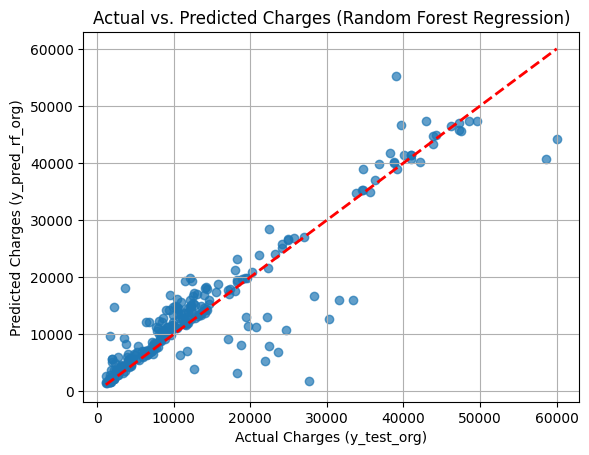

In [68]:
plt.scatter(y_test_org, y_pred_rf_org, alpha=0.7)
plt.plot([y_test_org.min(), y_test_org.max()], [y_test_org.min(), y_test_org.max()], 'r--', lw=2)
plt.xlabel("Actual Charges (y_test_org)")
plt.ylabel("Predicted Charges (y_pred_rf_org)")
plt.title("Actual vs. Predicted Charges (Random Forest Regression)")
plt.grid(True)
plt.show()

# **Evaluating Random Forest Regression model performance**

In [69]:
from sklearn.metrics import r2_score
r2_score(y_test_org,y_pred_rf_org)

0.8513498618921808